# Machine Learning Tutorial- Individual Assignment
**Student ID:** 24109506

🔗 **Source Code & Repository:** [Click here to view the GitHub Repository](https://github.com/Mazed-MZ/Machine-Learning-Tutorial-Individual-Assignment.git)

---

Success! Dataset generated and saved as 'athlete_injury_data.csv'


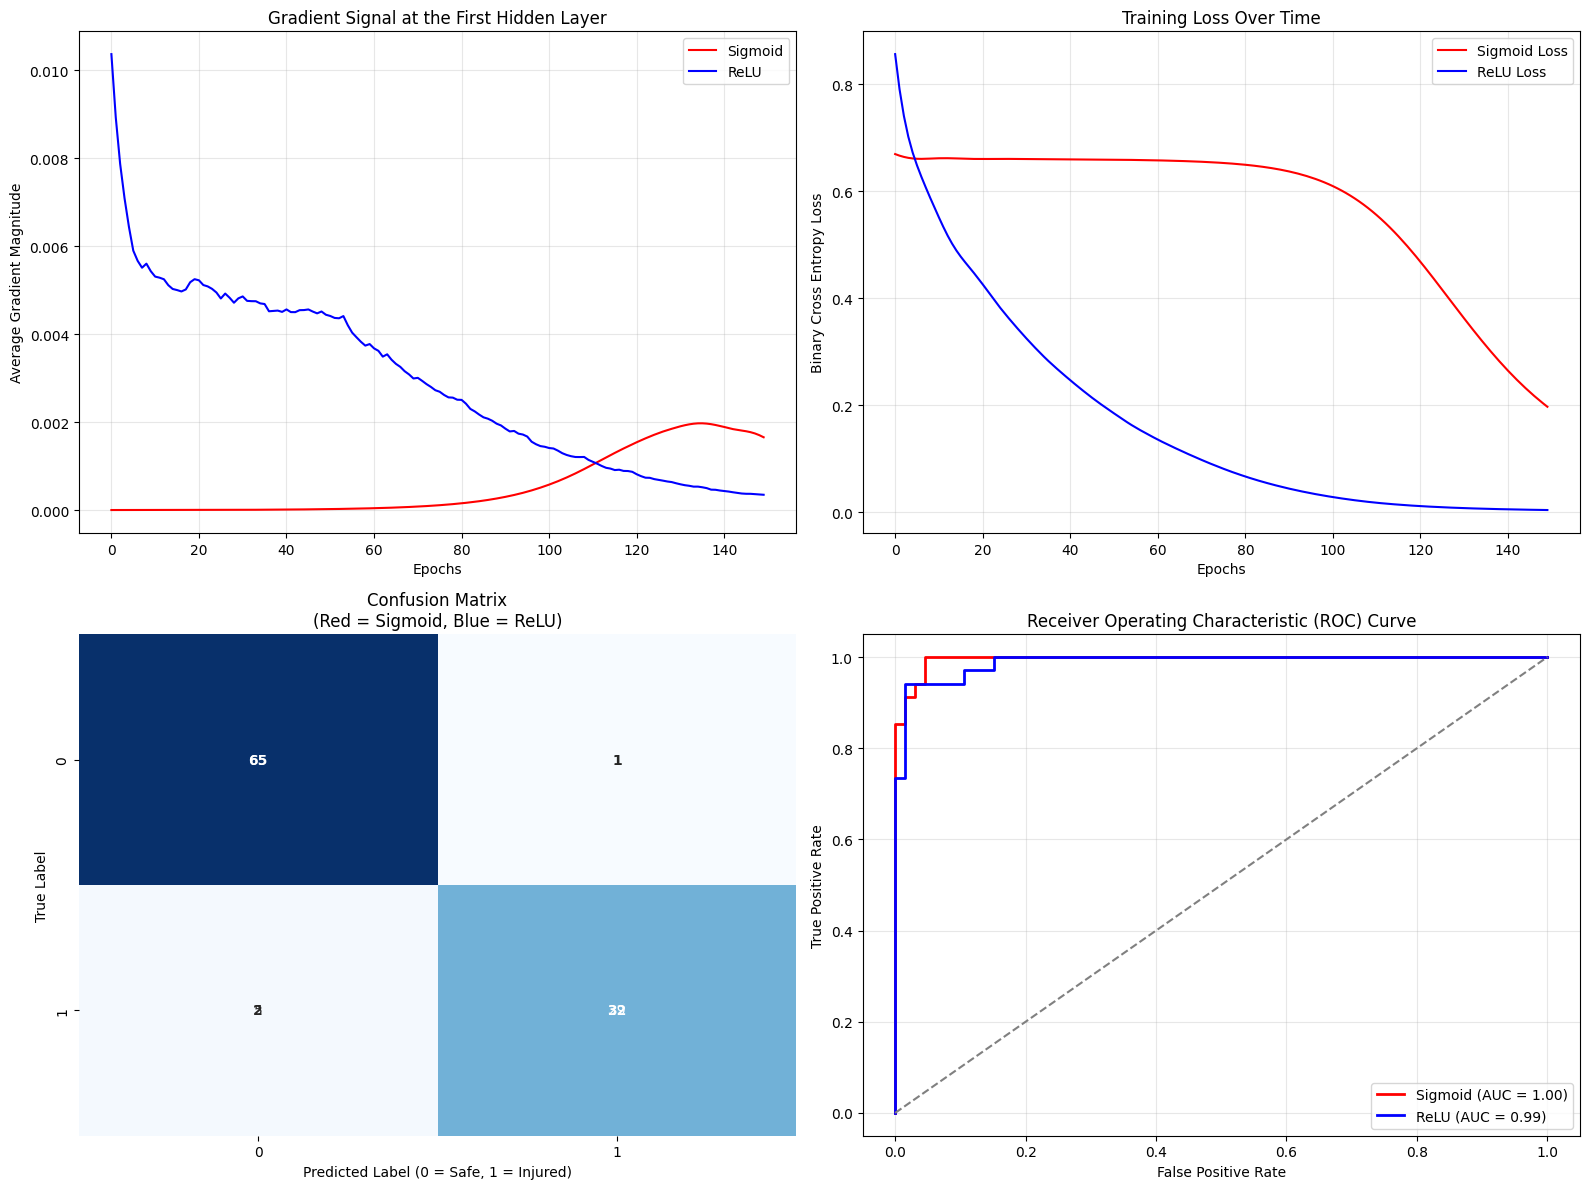

In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc

# ---------------------------------------------------------
# 1. Generate Athlet Injury Dataset
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 500

# Generate the 10 biometric features
data = {
    'Age': np.random.randint(18, 35, n_samples),
    'Weight_kg': np.random.uniform(60, 100, n_samples).round(1),
    'Height_cm': np.random.uniform(160, 200, n_samples).round(1),
    'Training_Hours_Weekly': np.random.uniform(5, 25, n_samples).round(1),
    'Average_Heart_Rate': np.random.randint(50, 80, n_samples),
    'Sleep_Hours_Nightly': np.random.uniform(4, 10, n_samples).round(1),
    'Sprint_Speed_kmh': np.random.uniform(20, 35, n_samples).round(1),
    'Muscle_Asymmetry_Pct': np.random.uniform(0, 15, n_samples).round(1),
    'Previous_Injuries': np.random.randint(0, 4, n_samples),
    'Stress_Level_Score': np.random.randint(1, 10, n_samples)
}

df = pd.DataFrame(data)

# Create the non-linear target variable (Injury_Risk)
risk_score = (
    (df['Training_Hours_Weekly'] / 25) * 0.4 +
    ((10 - df['Sleep_Hours_Nightly']) / 6) * 0.3 +
    (df['Muscle_Asymmetry_Pct'] / 15) * 0.3
)

# Convert risk score to binary outcome (1 = High Risk/Injured, 0 = Low Risk)
df['Injury_Risk'] = (risk_score > 0.6).astype(int)

# Save directly to CSV
file_name = 'athlete_injury_data.csv'
df.to_csv(file_name, index=False)

print(f"Success! Dataset generated and saved as '{file_name}'")
# ---------------------------------------------------------
# 2. Data Preprocessing
# ---------------------------------------------------------
df = pd.read_csv('athlete_injury_data.csv')
X = df.drop('Injury_Risk', axis=1).values
y = df['Injury_Risk'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_tensor = torch.FloatTensor(scaler.fit_transform(X_train))
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(scaler.transform(X_test))
y_test_tensor = torch.FloatTensor(y_test)

# ---------------------------------------------------------
# 3. Model Architecture & Initialization Techniques
# ---------------------------------------------------------
class DeepMLP(nn.Module):
    def __init__(self, activation_fn, init_type):
        super(DeepMLP, self).__init__()
        self.layers = nn.ModuleList([
            nn.Linear(10, 32), nn.Linear(32, 32),
            nn.Linear(32, 32), nn.Linear(32, 32),
            nn.Linear(32, 32)
        ])
        self.out = nn.Linear(32, 1)
        self.activation = activation_fn

        # Apply specific Weight Initialization
        for m in self.layers:
            if init_type == 'xavier':
                nn.init.xavier_normal_(m.weight)
            elif init_type == 'he':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.xavier_normal_(self.out.weight)

    def forward(self, x):
        for layer in self.layers:
            x = self.activation(layer(x))
        return torch.sigmoid(self.out(x))

torch.manual_seed(42)
model_sig = DeepMLP(nn.Sigmoid(), 'xavier')
model_relu = DeepMLP(nn.ReLU(), 'he')

criterion = nn.BCELoss()
opt_sig = optim.Adam(model_sig.parameters(), lr=0.001)
opt_relu = optim.Adam(model_relu.parameters(), lr=0.001)

# ---------------------------------------------------------
# 4. Training Loop & Gradient Tracking
# ---------------------------------------------------------
epochs = 150
loss_sig_history, loss_relu_history = [], []
grad_sig_history, grad_relu_history = [], []

for epoch in range(epochs):
    # Train Sigmoid
    opt_sig.zero_grad()
    loss_s = criterion(model_sig(X_train_tensor), y_train_tensor)
    loss_s.backward()
    loss_sig_history.append(loss_s.item())
    grad_sig_history.append(model_sig.layers[0].weight.grad.abs().mean().item())
    opt_sig.step()

    # Train ReLU
    opt_relu.zero_grad()
    loss_r = criterion(model_relu(X_train_tensor), y_train_tensor)
    loss_r.backward()
    loss_relu_history.append(loss_r.item())
    grad_relu_history.append(model_relu.layers[0].weight.grad.abs().mean().item())
    opt_relu.step()

# ---------------------------------------------------------
# 5. Generate Advanced Outputs and Figures
# ---------------------------------------------------------
model_sig.eval()
model_relu.eval()
with torch.no_grad():
    y_pred_prob_sig = model_sig(X_test_tensor).numpy()
    y_pred_prob_relu = model_relu(X_test_tensor).numpy()

y_pred_sig = (y_pred_prob_sig > 0.5).astype(int)
y_pred_relu = (y_pred_prob_relu > 0.5).astype(int)

# --- Set up a 2x2 grid for plotting ---
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Gradient Flow
axs[0, 0].plot(grad_sig_history, label="Sigmoid", color="red")
axs[0, 0].plot(grad_relu_history, label="ReLU", color="blue")
axs[0, 0].set_title("Gradient Signal at the First Hidden Layer")
axs[0, 0].set_xlabel("Epochs")
axs[0, 0].set_ylabel("Average Gradient Magnitude")
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Plot 2: Loss Curve
axs[0, 1].plot(loss_sig_history, label="Sigmoid Loss", color="red")
axs[0, 1].plot(loss_relu_history, label="ReLU Loss", color="blue")
axs[0, 1].set_title("Training Loss Over Time")
axs[0, 1].set_xlabel("Epochs")
axs[0, 1].set_ylabel("Binary Cross Entropy Loss")
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# Plot 3: Confusion Matrices (Combined)
cm_sig = confusion_matrix(y_test, y_pred_sig)
cm_relu = confusion_matrix(y_test, y_pred_relu)

sns.heatmap(cm_sig, annot=True, fmt='d', ax=axs[1, 0], cmap='Reds', cbar=False, alpha=0.7)
sns.heatmap(cm_relu, annot=True, fmt='d', ax=axs[1, 0], cmap='Blues', cbar=False,
            mask=(cm_relu==0), annot_kws={"weight": "bold"})
axs[1, 0].set_title("Confusion Matrix\n(Red = Sigmoid, Blue = ReLU)")
axs[1, 0].set_xlabel("Predicted Label (0 = Safe, 1 = Injured)")
axs[1, 0].set_ylabel("True Label")

# Plot 4: ROC Curve
fpr_sig, tpr_sig, _ = roc_curve(y_test, y_pred_prob_sig)
fpr_relu, tpr_relu, _ = roc_curve(y_test, y_pred_prob_relu)
axs[1, 1].plot(fpr_sig, tpr_sig, color='red', lw=2, label=f'Sigmoid (AUC = {auc(fpr_sig, tpr_sig):.2f})')
axs[1, 1].plot(fpr_relu, tpr_relu, color='blue', lw=2, label=f'ReLU (AUC = {auc(fpr_relu, tpr_relu):.2f})')
axs[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axs[1, 1].set_title("Receiver Operating Characteristic (ROC) Curve")
axs[1, 1].set_xlabel("False Positive Rate")
axs[1, 1].set_ylabel("True Positive Rate")
axs[1, 1].legend(loc="lower right")
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📚 References and Resources Used
The following academic papers, documentation, and educational resources were used to prepare this code and the accompanying tutorial on the Vanishing Gradient problem:

* Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. *Proceedings of the Thirteenth International Conference on Artificial Intelligence and Statistics (AISTATS)*, 9, 249–256. [Link to PDF](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)
* Nair, V., & Hinton, G. E. (2010). Rectified Linear Units Improve Restricted Boltzmann Machines. *Proceedings of the 27th International Conference on Machine Learning (ICML)*, 27, 807–814. [Link to PDF](https://icml.cc/Conferences/2010/papers/432.pdf)
* Brownlee, J. (2020). A Gentle Introduction to the Rectified Linear Unit (ReLU). *Machine Learning Mastery*. [Link](https://machinelearningmastery.com/rectified-linear-activation-function-for-deep-learning-neural-networks/)
* Stanford Vision Lab. (n.d.). Neural Networks Part 1: Setting up the Architecture. *CS231n: Convolutional Neural Networks for Visual Recognition*. [Link](https://cs231n.github.io/neural-networks-1/#actfun)
* Paszke, A., et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. *Advances in Neural Information Processing Systems*, 32. [PyTorch Documentation](https://pytorch.org/docs/stable/index.html)
* Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. [Scikit-learn Documentation](https://scikit-learn.org/stable/)